## 1. Problem Definition

### Business/Research Problem
Urban traffic congestion causes delays, higher fuel consumption, and lower transport efficiency. The goal of this project is to predict traffic volume from historical data so stakeholders can improve planning, reduce congestion risk, and support better operational decisions.

### Analytical Questions
1. At what hours and on which days does congestion peak?
2. Which features (time, day, weather-related fields if available, etc.) are the strongest drivers of traffic volume?
3. Can machine learning models predict traffic volume accurately enough to be useful for planning?
4. Which model provides the best trade-off between prediction accuracy and interpretability?

### Hypotheses
- H1: Traffic volume is significantly higher during peak commuting hours than off-peak hours.
- H2: Traffic volume differs significantly by day of week (weekday vs weekend behavior).
- H3: Time-based features (hour and day) explain a substantial portion of traffic variation.
- H4: Non-linear models (e.g., tree-based models) will outperform linear regression on prediction error metrics.

## 2. Data Collection

### Dataset Source
The data was obtained from the Kaggle Traffic Prediction Dataset and downloaded locally.

### Files Used
- Traffic.csv
- TrafficTwoMonth.csv

### Features
The dataset has 9 columns:
- Time
- Date
- Day of the week
- CarCount
- BikeCount
- BusCount
- TruckCount
- Total
- Traffic Situation

### Size
- Traffic.csv: 2,976 rows
- TrafficTwoMonth.csv: 5,952 rows
- Total before cleaning: 8,928 rows

### Data Types (Simple View)
- Text/date-time fields: Time, Date, Day of the week, Traffic Situation
- Numeric fields: CarCount, BikeCount, BusCount, TruckCount, Total

In [7]:
import os
import pandas as pd

path = os.path.join(os.getcwd(), "Traffic_Dataset")

print(path)
print(os.listdir(path))

/Users/youssefbarakat/Documents/GitHub/Big_Data_Project/Traffic_Dataset
['Traffic.csv', 'TrafficTwoMonth.csv']


In [8]:
df1 = pd.read_csv(os.path.join(path, "Traffic.csv"))
df2 = pd.read_csv(os.path.join(path, "TrafficTwoMonth.csv"))

In [9]:
df = pd.concat([df1, df2], ignore_index=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df[:10]

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal
5,1:15:00 AM,10,Tuesday,44,0,5,4,53,low
6,1:30:00 AM,10,Tuesday,37,0,1,4,42,low
7,1:45:00 AM,10,Tuesday,42,4,4,5,55,low
8,2:00:00 AM,10,Tuesday,51,0,9,7,67,low
9,2:15:00 AM,10,Tuesday,34,0,4,7,45,low


In [10]:
# Part 2: Data Collection summary (simple and clear)

# Basic sizes from each source file
rows_file_1 = len(df1)
rows_file_2 = len(df2)
rows_total_before_cleaning = rows_file_1 + rows_file_2

print("Files used:", "Traffic.csv, TrafficTwoMonth.csv")
print("Rows in Traffic.csv:", rows_file_1)
print("Rows in TrafficTwoMonth.csv:", rows_file_2)
print("Total rows before cleaning:", rows_total_before_cleaning)
print("Rows after merge + duplicate removal:", len(df))
print("Number of features:", df.shape[1])

print("\nFeatures:")
for col in df.columns:
    print("-", col)

dtype_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": [str(df[col].dtype) for col in df.columns],
    "Simple Type": ["Numeric" if pd.api.types.is_numeric_dtype(df[col]) else "Text/Date-Time" for col in df.columns]
})

print("\nFeature data types:")
dtype_summary

Files used: Traffic.csv, TrafficTwoMonth.csv
Rows in Traffic.csv: 2976
Rows in TrafficTwoMonth.csv: 5952
Total rows before cleaning: 8928
Rows after merge + duplicate removal: 6324
Number of features: 9

Features:
- Time
- Date
- Day of the week
- CarCount
- BikeCount
- BusCount
- TruckCount
- Total
- Traffic Situation

Feature data types:


,Feature,Data Type,Simple Type
0,Time,str,Text/Date-Time
1,Date,int64,Numeric
2,Day of the week,str,Text/Date-Time
3,CarCount,int64,Numeric
4,BikeCount,int64,Numeric
5,BusCount,int64,Numeric
6,TruckCount,int64,Numeric
7,Total,int64,Numeric
8,Traffic Situation,str,Text/Date-Time


## 3. Data Cleaning & Preparation


- Handle missing values
- Reduce outlier impact
- Encode categorical variables
- Normalize numeric features (if needed for modeling)

In [ ]:
# Part 3: Data Cleaning & Preparation (simple pipeline)

df_clean = df.copy()

# 1) Handle missing values
missing_before = df_clean.isnull().sum().sum()

numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()
cat_cols = df_clean.select_dtypes(exclude="number").columns.tolist()

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

missing_after = df_clean.isnull().sum().sum()

# 2) Handle outliers using IQR capping on numeric columns
for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

# 3) Encode categorical columns by direct mapping
traffic_mapping = {"low": 0, "normal": 1, "high": 2, "heavy": 3}
day_mapping = {
    "monday": 0, "tuesday": 1, "wednesday": 2, "thursday": 3,
    "friday": 4, "saturday": 5, "sunday": 6
}

df_prepared = df_clean.copy()
traffic_norm = df_prepared["Traffic Situation"].astype(str).str.strip().str.lower()
day_norm = df_prepared["Day of the week"].astype(str).str.strip().str.lower()

unknown_traffic_labels = sorted(set(traffic_norm.unique()) - set(traffic_mapping.keys()))
unknown_day_labels = sorted(set(day_norm.unique()) - set(day_mapping.keys()))

df_prepared["Traffic Situation"] = traffic_norm.map(traffic_mapping).fillna(-1).astype(int)
df_prepared["Day of the week"] = day_norm.map(day_mapping).fillna(-1).astype(int)

# Use hour + minute/60 for Time as a float
parsed_time = pd.to_datetime(df_prepared["Time"], errors='coerce')
df_prepared["Time"] = (parsed_time.dt.hour + parsed_time.dt.minute / 60)
invalid_time_count = df_prepared["Time"].isna().sum()

# 4) Normalize only the original numeric measurement columns
for col in numeric_cols:
    col_min = df_prepared[col].min()
    col_max = df_prepared[col].max()
    if col_max != col_min:
        df_prepared[col] = (df_prepared[col] - col_min) / (col_max - col_min)
    else:
        df_prepared[col] = 0.0

print("Missing values before:", int(missing_before))
print("Missing values after:", int(missing_after))
print("Original shape:", df.shape)
print("After cleaning shape:", df_clean.shape)
print("After encoding shape:", df_prepared.shape)

print("\nEncoded 'Traffic Situation' value counts:")
print(df_prepared["Traffic Situation"].value_counts(dropna=False).sort_index())
print("\nEncoded 'Day of the week' value counts:")
print(df_prepared["Day of the week"].value_counts(dropna=False).sort_index())
print("\nFirst 5 rows of prepared data:")
df_prepared.head()

Missing values before: 0
Missing values after: 0
Original shape: (6324, 9)
After cleaning shape: (6324, 9)
After encoding shape: (6324, 9)

Encoded 'Traffic Situation' value counts:
Traffic Situation
0     834
1    3858
2     495
3    1137
Name: count, dtype: int64

Encoded 'Day of the week' value counts:
Day of the week
0     814
1    1011
2    1012
3    1020
4     832
5     819
6     816
Name: count, dtype: int64

First 5 rows of prepared data:


/var/folders/ph/90hk2k6939q3csdkd211f59c0000gn/T/ipykernel_34503/3924140373.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_time = pd.to_datetime(df_prepared["Time"], errors='coerce')


,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,0.00,0.3,1,0.148571,0.000000,0.082474,0.076190,0.069767,0
1,0.25,0.3,1,0.251429,0.000000,0.061856,0.057143,0.131783,0
2,0.50,0.3,1,0.234286,0.000000,0.061856,0.114286,0.131783,0
3,0.75,0.3,1,0.262857,0.000000,0.041237,0.095238,0.143411,0
4,1.00,0.3,1,0.297143,0.139535,0.309278,0.304762,0.282946,1


## 4. Exploratory Data Analysis (EDA)- 5. Data Visualization


- Perform descriptive statistics.
- Identify patterns and trends across time.
- Check correlations between numeric variables.
- Power BI used for dashboard and other visulisations.

Top 10 worst congestion windows (Day + Hour):


,Day Label,Hour,Congestion Share %
112,Thursday,16,92.5
40,Monday,16,90.6
89,Sunday,17,90.6
64,Saturday,16,90.6
41,Monday,17,90.6
12,Friday,12,90.6
113,Thursday,17,90.0
161,Wednesday,17,87.5
14,Friday,14,87.5
65,Saturday,17,87.5


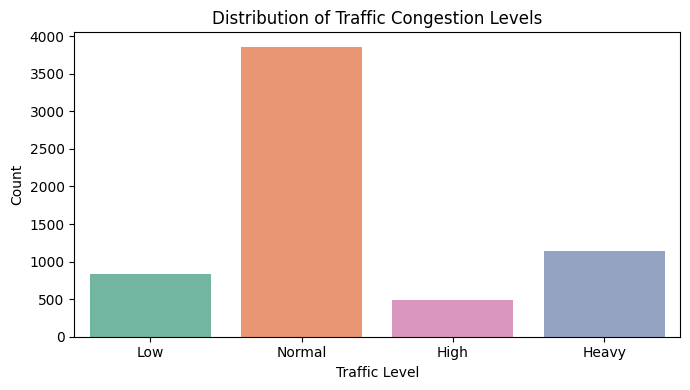

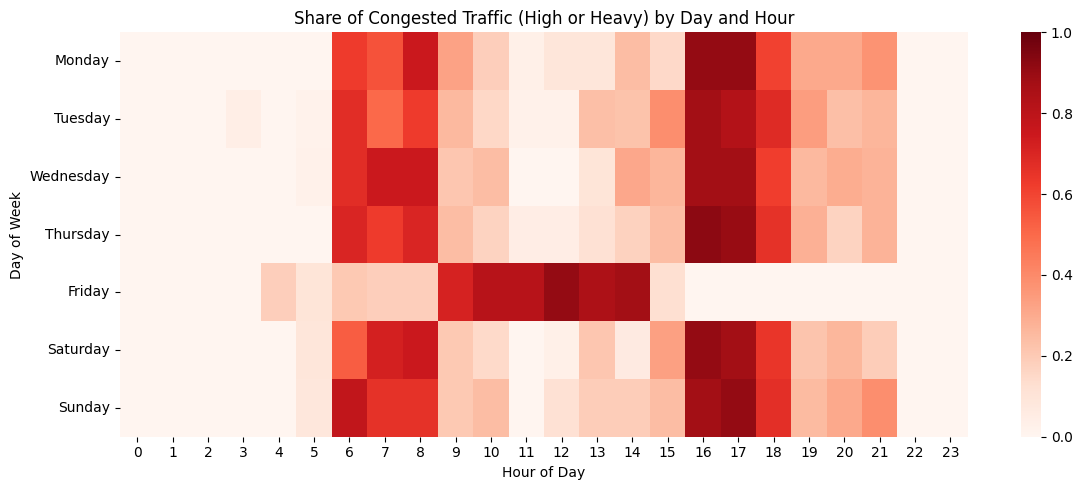

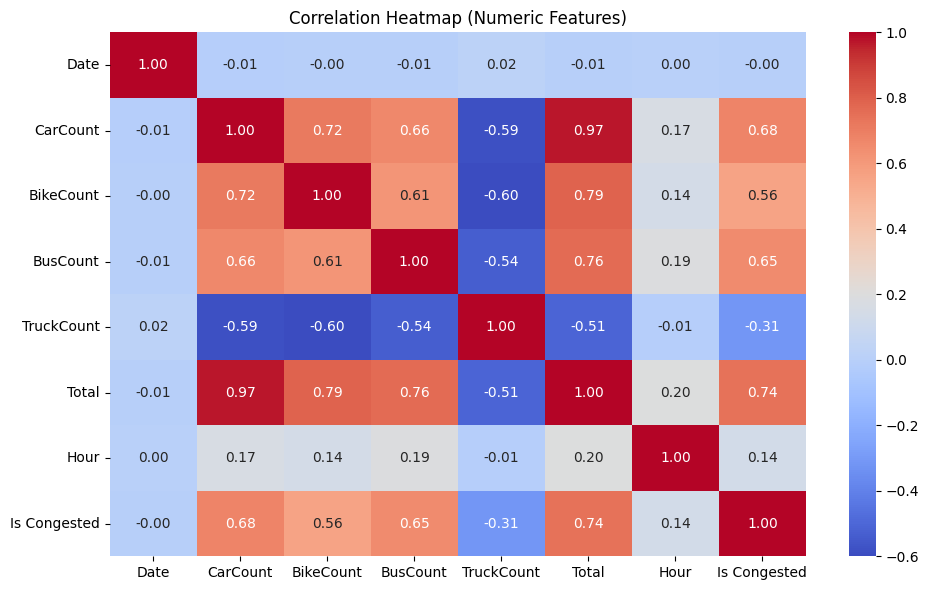

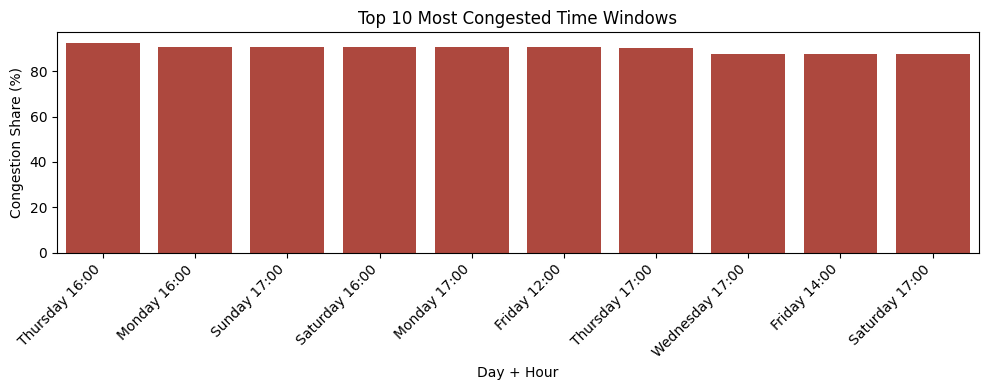

In [ ]:
# Part 4: Exploratory Data Analysis (focused + actionable)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

eda_df = df_clean.copy()

# 1) Robust label preparation

traffic_str = eda_df["Traffic Situation"].astype(str).str.strip().str.lower()
traffic_label_map = {
    "0": "Low", "low": "Low",
    "1": "Normal", "normal": "Normal", "medium": "Normal",
    "2": "High", "high": "High",
    "3": "Heavy", "heavy": "Heavy",
}
eda_df["Traffic Level"] = traffic_str.map(traffic_label_map).fillna("Unknown")

raw_time = eda_df["Time"]
if pd.api.types.is_numeric_dtype(raw_time):
    eda_df["Hour"] = raw_time.fillna(0).astype(float).round().astype(int).clip(0, 23)
else:
    parsed_time = pd.to_datetime(raw_time, format="%I:%M:%S %p", errors="coerce")
    if parsed_time.isna().any():
        fallback = pd.to_datetime(raw_time[parsed_time.isna()], errors="coerce")
        parsed_time.loc[parsed_time.isna()] = fallback
    eda_df["Hour"] = parsed_time.dt.hour

# Day labels for readable heatmap rows
day_str = eda_df["Day of the week"].astype(str).str.strip().str.lower()
day_label_map = {
    "0": "Monday", "monday": "Monday",
    "1": "Tuesday", "tuesday": "Tuesday",
    "2": "Wednesday", "wednesday": "Wednesday",
    "3": "Thursday", "thursday": "Thursday",
    "4": "Friday", "friday": "Friday",
    "5": "Saturday", "saturday": "Saturday",
    "6": "Sunday", "sunday": "Sunday",
}
eda_df["Day Label"] = day_str.map(day_label_map)

level_order = ["Low", "Normal", "High", "Heavy"]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


# 2) Insight summary table
eda_df["Is Congested"] = eda_df["Traffic Level"].isin(["High", "Heavy"]).astype(int)
slot_congestion = (
    eda_df.groupby(["Day Label", "Hour"], as_index=False)["Is Congested"]
    .mean()
    .rename(columns={"Is Congested": "Congestion Share"})
)
slot_congestion["Congestion Share %"] = (slot_congestion["Congestion Share"] * 100).round(1)
worst_slots = slot_congestion.sort_values("Congestion Share", ascending=False).head(10)

print("Top 10 worst congestion windows (Day + Hour):")
display(worst_slots[["Day Label", "Hour", "Congestion Share %"]])


# 3) Distribution of traffic congestion levels 
plt.figure(figsize=(7, 4))
sns.countplot(
    data=eda_df,
    x="Traffic Level",
    order=level_order,
    hue="Traffic Level",
    palette="Set2",
    legend=False,
)
plt.title("Distribution of Traffic Congestion Levels")
plt.xlabel("Traffic Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 4) Heatmap of congestion share 
pivot = eda_df.pivot_table(
    index="Day Label",
    columns="Hour",
    values="Is Congested",
    aggfunc="mean"
)
pivot = pivot.reindex(day_order).dropna(how="all")

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, cmap="Reds", vmin=0, vmax=1, annot=False)
plt.title("Share of Congested Traffic (High or Heavy) by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

# 5) Simple correlation heatmap 

numeric_cols = eda_df.select_dtypes(include="number")
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


# 6) Top congested slots bar chart

plot_slots = worst_slots.copy()
plot_slots["Slot"] = plot_slots["Day Label"] + " " + plot_slots["Hour"].astype(int).astype(str) + ":00"

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_slots, x="Slot", y="Congestion Share %", color="#c0392b")
plt.title("Top 10 Most Congested Time Windows")
plt.xlabel("Day + Hour")
plt.ylabel("Congestion Share (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

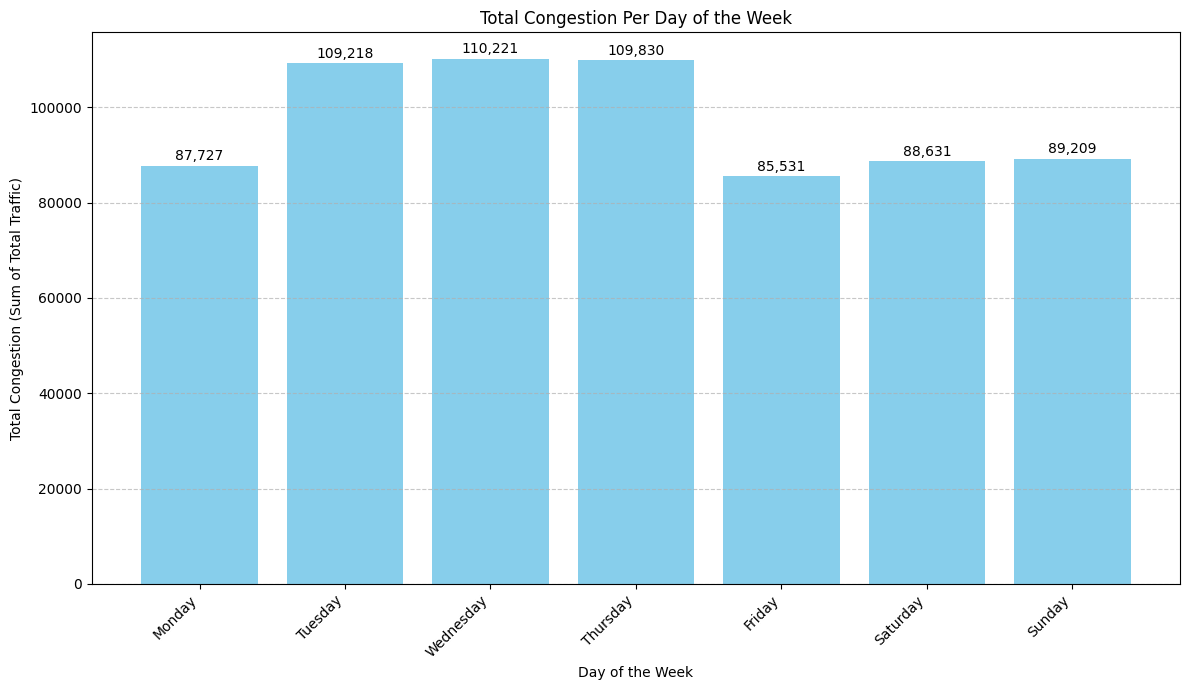

In [8]:
# Calculate the sum of 'Total' traffic for each 'Day of the week'
total_congestion_per_day = df.groupby('Day of the week')['Total'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Create a bar chart
plt.figure(figsize=(12, 7))
plt.bar(total_congestion_per_day.index, total_congestion_per_day.values, color='skyblue')

# Add values on top of bars
for index, value in enumerate(total_congestion_per_day.values):
    plt.text(index, value + 500, f'{value:,.0f}', ha='center', va='bottom', fontsize=10)

plt.xlabel("Day of the Week")
plt.ylabel("Total Congestion (Sum of Total Traffic)")
plt.title("Total Congestion Per Day of the Week")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Model Planning and Building

- Data split into training and testing sets
- model trined and tune basic parameters
- 3 Models trained: DecisionTreeClassifier, Logistic Regerssion and Random Forest

### 6.1. splitting data into training and testing:

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Use prepared data from Step 3 (already encoded)
model_df = df_prepared.copy()

# Target and features
target_col = "Traffic Situation"
X = model_df.drop(columns=[target_col])
y = model_df[target_col]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5059, 8)
Test shape: (1265, 8)


### 6.2. DecisionTreeClassifier

In [20]:
# 6.2 Decision Tree Classifier

# Basic parameter tuning: try a few max_depth values
depth_options = [3, 5, 7, None]
results = []

for depth in depth_options:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append((depth, acc))

# Pick best depth and train final model
best_depth, best_acc = max(results, key=lambda x: x[1])
dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print("Decision Tree - Accuracy by max_depth:")
for depth, acc in results:
    print(f"max_depth={depth}: {acc:.4f}")

print(f"\nBest max_depth: {best_depth}")
print(f"Final Accuracy: {best_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_preds))

Decision Tree - Accuracy by max_depth:
max_depth=3: 0.8285
max_depth=5: 0.9368
max_depth=7: 0.9352
max_depth=None: 0.8917

Best max_depth: 5
Final Accuracy: 0.9368

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       167
           1       0.97      0.93      0.95       772
           2       1.00      0.76      0.86        99
           3       1.00      1.00      1.00       227

    accuracy                           0.94      1265
   macro avg       0.93      0.92      0.92      1265
weighted avg       0.95      0.94      0.94      1265



### 6.3.Logistic Regression:

In [21]:
# 6.3 Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_preds)
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, log_preds))

Logistic Regression Accuracy: 0.8316

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.48      0.57       167
           1       0.83      0.93      0.88       772
           2       0.67      0.34      0.45        99
           3       0.92      0.97      0.95       227

    accuracy                           0.83      1265
   macro avg       0.78      0.68      0.71      1265
weighted avg       0.82      0.83      0.82      1265



### 6.4. Random Forest:

In [22]:
# 6.4 Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.8862

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.74       167
           1       0.92      0.90      0.91       772
           2       0.75      0.75      0.75        99
           3       0.99      1.00      0.99       227

    accuracy                           0.89      1265
   macro avg       0.84      0.85      0.85      1265
weighted avg       0.89      0.89      0.89      1265



## 7. Model Comparison and Selection

- Compare the three model accuracies from Step 6
- Select the best model based on test accuracy
- Keep the final choice simple and clear

In [23]:
# Step 7: Compare models and choose the best one
required_scores = ["best_acc", "log_acc", "rf_acc"]
missing_scores = [name for name in required_scores if name not in globals()]

if missing_scores:
    print("Run Step 6 model cells first. Missing:", missing_scores)
else:
    scores = {
        "Decision Tree": best_acc,
        "Logistic Regression": log_acc,
        "Random Forest": rf_acc,
    }

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    print("Model Accuracy Ranking:")
    for model_name, score in ranked:
        print(f"- {model_name}: {score:.4f}")

    best_model, best_score = ranked[0]
    print(f"\nSelected Model: {best_model}")
    print(f"Selected Accuracy: {best_score:.4f}")

Model Accuracy Ranking:
- Decision Tree: 0.9368
- Random Forest: 0.8862
- Logistic Regression: 0.8316

Selected Model: Decision Tree
Selected Accuracy: 0.9368
